In [1]:

import pandas as pd                 # 用于读取csv、处理表格数据
import numpy as np                  # 数值计算
from sklearn.neighbors import KNeighborsClassifier   # KNN分类器
from sklearn.preprocessing import StandardScaler     # 特征标准化（KNN必须）
from sklearn.impute import SimpleImputer             # sklearn官方缺失值填充器
from sklearn.model_selection import train_test_split # 划分训练验证集
from sklearn.metrics import accuracy_score           # 计算准确率
import joblib  
from sklearn.model_selection import cross_val_score

train = pd.read_csv("train.csv")    # 训练集：含特征 + 是否生还标签
test = pd.read_csv("test.csv")      # 测试集：只有特征，没有标签

test_ids = test["PassengerId"]      # 保存测试集乘客编号（最后提交必须）


features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]

X_train = train[features].copy()           # 训练集输入特征
X_test = test[features].copy()            # 测试集输入特征
y_train = train["Survived"].copy()         # 训练集标签：0死亡 / 1生还


X_train["Sex"] = X_train["Sex"].map({"male": 0, "female": 1})   # 性别数字化
X_test["Sex"] = X_test["Sex"].map({"male": 0, "female": 1})

# X_train["Embarked"] = X_train["Embarked"].map({"C": 0, "Q": 1, "S": 2}) # 登船口数字化
# X_test["Embarked"] = X_test["Embarked"].map({"C": 0, "Q": 1, "S": 2})

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


imputer = SimpleImputer(strategy="median")

# imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)  # 训练集：fit + transform
X_val_imp = imputer.transform(X_val)          # 验证集：只 transform


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)  # 训练集：学均值方差

X_val_scaled = scaler.transform(X_val_imp)   

# X_train_clean = imputer.fit_transform(X_train)   # 拟合训练集并填充空值
# X_test_clean = imputer.transform(X_test)         # 用训练集规则填充测试集（防止数据泄露）

# scaler = StandardScaler()                        # 标准化器：均值0，方差1
# X_train_scaled = scaler.fit_transform(X_train_clean)  # 训练集标准化
# X_test_scaled = scaler.transform(X_test_clean)        # 测试集按同样规则标准化





In [8]:

from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# 定义要搜索的 K 和 p
k_list = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
p_list = [1,2,3,0]

# 交叉验证的评价指标
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}
# 开始遍历
results = []
for k in k_list:
    for p in p_list:
        
        if(p!=0) :
            
            knn = KNeighborsClassifier(n_neighbors=k, p=p,weights='uniform')
        else :
            knn = KNeighborsClassifier(n_neighbors=k, metric='chebyshev',weights='uniform')
        
        # 在 训练集 训练
        knn.fit(X_train_scaled, y_train)
        
        # 在 验证集 预测
        y_pred = knn.predict(X_val_scaled)
        

        acc = accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)
        recall = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        
        # 保存结果
        results.append([k, p, acc, precision, recall, f1])

# 保存到表格（加入 f1）
df = pd.DataFrame(results, columns=["K", "distance", "accuracy", "precision", "recall", "f1"])

In [9]:
import matplotlib.pyplot as plt

def plot_knn_metric(df, k_list, metric_name, title, ylabel):
    plt.figure(figsize=(10, 5))
    
    
    # 画每条线
    for name in df["distance"].unique():
        sub = df[df["distance"] == name]
        plt.plot(sub["K"], sub[metric_name], marker='o', linewidth=2, label=name)
    
    # 样式
    plt.title(title, fontsize=14)
    plt.xlabel("K Value", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(k_list)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig(save_path)
    # print(f"✅ 已保存：{save_path}")

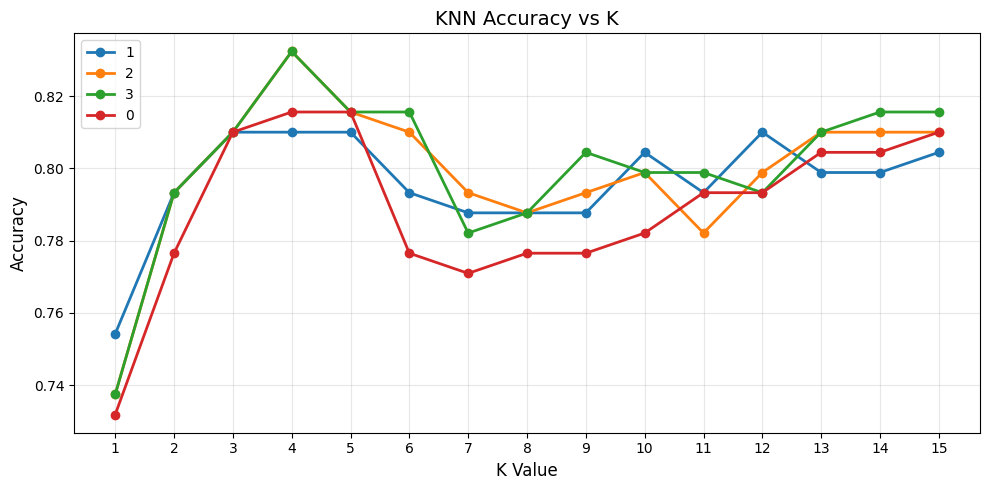

In [10]:
plot_knn_metric(df, k_list, "accuracy",  "KNN Accuracy vs K",   "Accuracy")




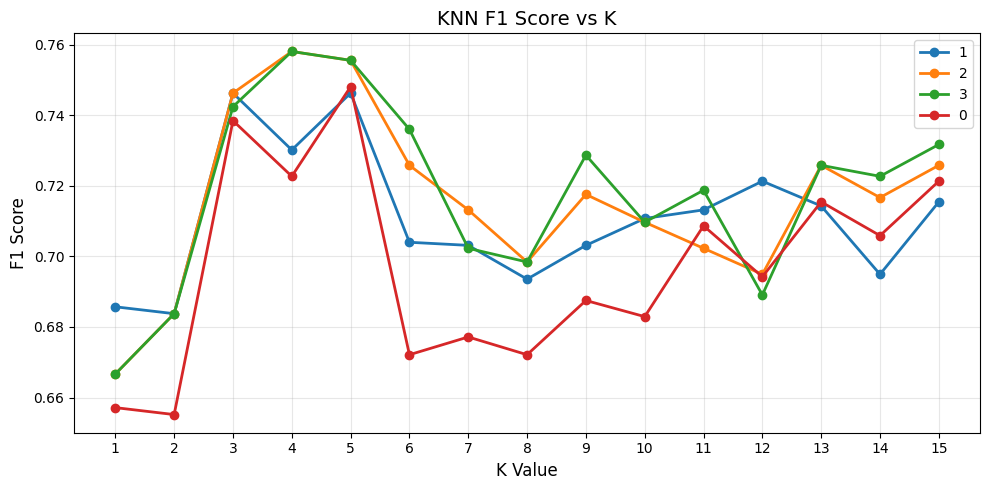

In [11]:
plot_knn_metric(df, k_list, "f1",        "KNN F1 Score vs K",   "F1 Score") 

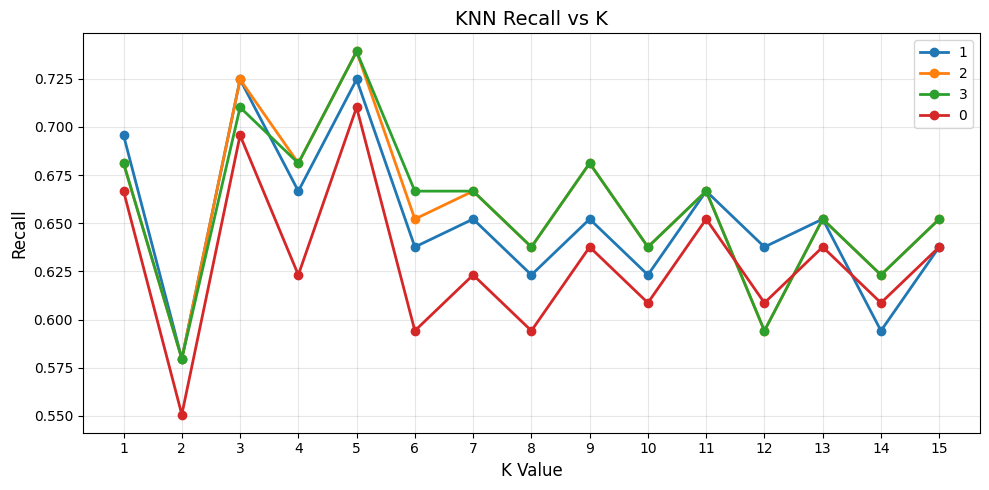

In [12]:
plot_knn_metric(df, k_list, "recall",    "KNN Recall vs K",     "Recall")

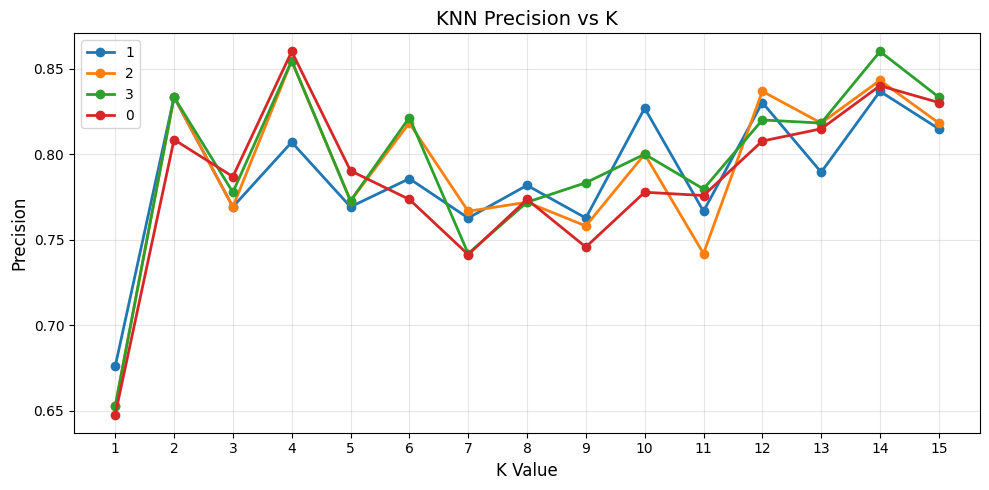

In [13]:
plot_knn_metric(df, k_list, "precision", "KNN Precision vs K",  "Precision")

In [8]:
model = KNeighborsClassifier(n_neighbors=5, p=2)
model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
y_pred = model.predict(X_test_scaled)

In [10]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": y_pred,
})

In [11]:
submission.to_csv("titanic_knn_result.csv", index=False)